In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder ,StandardScaler 

In [36]:
df=pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [38]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


# Data Cleaning

In [39]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.shape

(918, 12)

In [42]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

# EDA

<Axes: xlabel='HeartDisease', ylabel='count'>

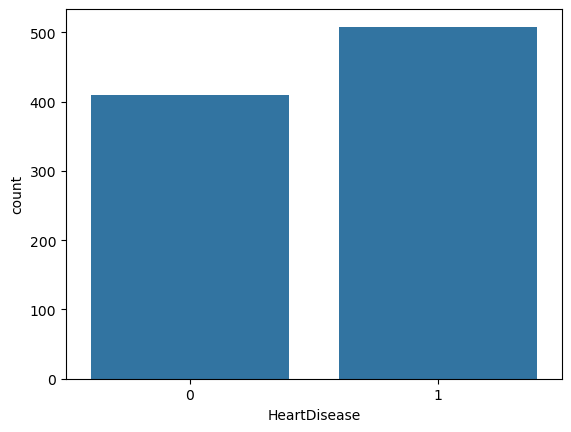

In [43]:
sns.countplot(x='HeartDisease', data=df)

<Axes: xlabel='Age', ylabel='Count'>

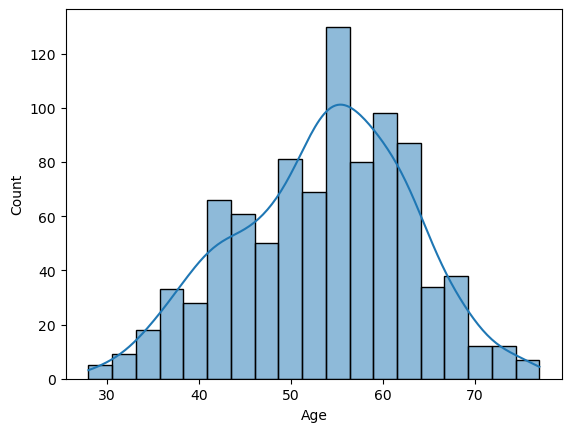

In [44]:
sns.histplot(df['Age'] ,kde=True)

<Axes: >

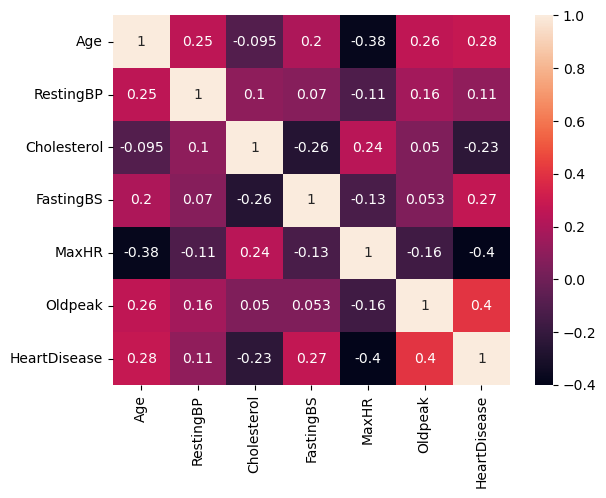

In [45]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Encoding

In [46]:
df.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1


In [47]:
le = LabelEncoder()
data = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for i in data:
    df[i] = le.fit_transform(df[i])
    

In [48]:
df.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1


# Feature Engineering

In [49]:
x = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# data splitting

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

# Feature Scaling

In [51]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Build KNN Model

In [52]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Prediction

In [53]:
y_pred = knn.predict(x_test)

# Evaluation

In [54]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report ,precision_score

accuracy_score(y_test, y_pred)

0.8478260869565217

In [55]:
confusion_matrix(y_test, y_pred)

array([[68,  9],
       [19, 88]])

In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        77
           1       0.91      0.82      0.86       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



# Hyperparameter Tuning

In [57]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [1,3,5,7,9],
    'metric': ['euclidean', 'manhattan']
}
knn=KNeighborsClassifier()

gcv = GridSearchCV(estimator=knn,param_grid=param_grid,cv=5,scoring='accuracy')

gcv.fit(x_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [1, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [58]:
gcv.best_params_

{'metric': 'manhattan', 'n_neighbors': 9}

In [59]:
print(gcv.best_score_)

0.8746808312366042


In [60]:
gcv.best_estimator_

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [61]:
result=pd.DataFrame(gcv.cv_results_)
result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002797,0.000563,0.006830,0.003057,euclidean,1,"{'metric': 'euclidean', 'n_neighbors': 1}",0.863946,0.877551,0.829932,0.768707,0.773973,0.822822,0.044837,10
1,0.002456,0.000279,0.005652,0.000973,euclidean,3,"{'metric': 'euclidean', 'n_neighbors': 3}",0.877551,0.877551,0.850340,0.816327,0.842466,0.852847,0.023101,8
2,0.001961,0.000149,0.004873,0.000633,euclidean,5,"{'metric': 'euclidean', 'n_neighbors': 5}",0.877551,0.870748,0.857143,0.829932,0.856164,0.858308,0.016348,3
3,0.001956,0.000188,0.004944,0.000510,euclidean,7,"{'metric': 'euclidean', 'n_neighbors': 7}",0.870748,0.870748,0.857143,0.843537,0.849315,0.858298,0.011045,4
4,0.002186,0.000243,0.004733,0.000076,euclidean,9,"{'metric': 'euclidean', 'n_neighbors': 9}",0.870748,0.870748,0.843537,0.823129,0.863014,0.854235,0.018463,6
5,0.002286,0.000692,0.004968,0.000576,manhattan,1,"{'metric': 'manhattan', 'n_neighbors': 1}",0.857143,0.843537,0.809524,0.795918,0.821918,0.825608,0.022225,9
6,0.002245,0.000284,0.006360,0.001645,manhattan,3,"{'metric': 'manhattan', 'n_neighbors': 3}",0.857143,0.891156,0.863946,0.823129,0.849315,0.856938,0.022005,5
7,0.002249,0.000263,0.005852,0.000459,manhattan,5,"{'metric': 'manhattan', 'n_neighbors': 5}",0.870748,0.891156,0.836735,0.829932,0.842466,0.854207,0.023114,7
8,0.002309,0.000409,0.005580,0.000889,manhattan,7,"{'metric': 'manhattan', 'n_neighbors': 7}",0.884354,0.897959,0.863946,0.829932,0.876712,0.870581,0.023122,2
9,0.002130,0.000153,0.005869,0.000483,manhattan,9,"{'metric': 'manhattan', 'n_neighbors': 9}",0.891156,0.884354,0.870748,0.836735,0.890411,0.874681,0.020336,1


In [62]:
result=pd.DataFrame(gcv.cv_results_)  
# how much cross validation table for each value
result[["param_metric","param_n_neighbors","mean_test_score"]]

,param_metric,param_n_neighbors,mean_test_score
0,euclidean,1,0.822822
1,euclidean,3,0.852847
2,euclidean,5,0.858308
3,euclidean,7,0.858298
4,euclidean,9,0.854235
5,manhattan,1,0.825608
6,manhattan,3,0.856938
7,manhattan,5,0.854207
8,manhattan,7,0.870581
9,manhattan,9,0.874681


In [63]:
knn = KNeighborsClassifier(n_neighbors=9 ,metric='manhattan')
knn.fit(x_train, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [64]:
y_pred = knn.predict(x_test)

In [65]:
accuracy_score(y_test, y_pred)

0.8967391304347826

In [66]:
confusion_matrix(y_test, y_pred)

array([[69,  8],
       [11, 96]])

In [67]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        77
           1       0.92      0.90      0.91       107

    accuracy                           0.90       184
   macro avg       0.89      0.90      0.89       184
weighted avg       0.90      0.90      0.90       184



In [69]:
import pickle

# save trained model
pickle.dump(knn, open('heart_model.pkl', 'wb'))

# save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [73]:
import sklearn
print(sklearn.__version__)

1.7.2
